## Hva er kunstig intelligens? ##


Store språkmodeller er bare én liten del av KI-feltet. Figuren viser hvor de hører hjemme:


*Merk at et nivå til er utelatt for enkelhets skyld: mellom maskinlæring og generative
modeller ligger **dyp læring** (nevrale nettverk).*

<img alt="KI-feltet: kunstig intelligens rommer regelbasert KI og maskinlæring; maskinlæring rommer klassifisering og generative modeller; generative modeller rommer store språkmodeller." style="max-width:100%; height:auto" src="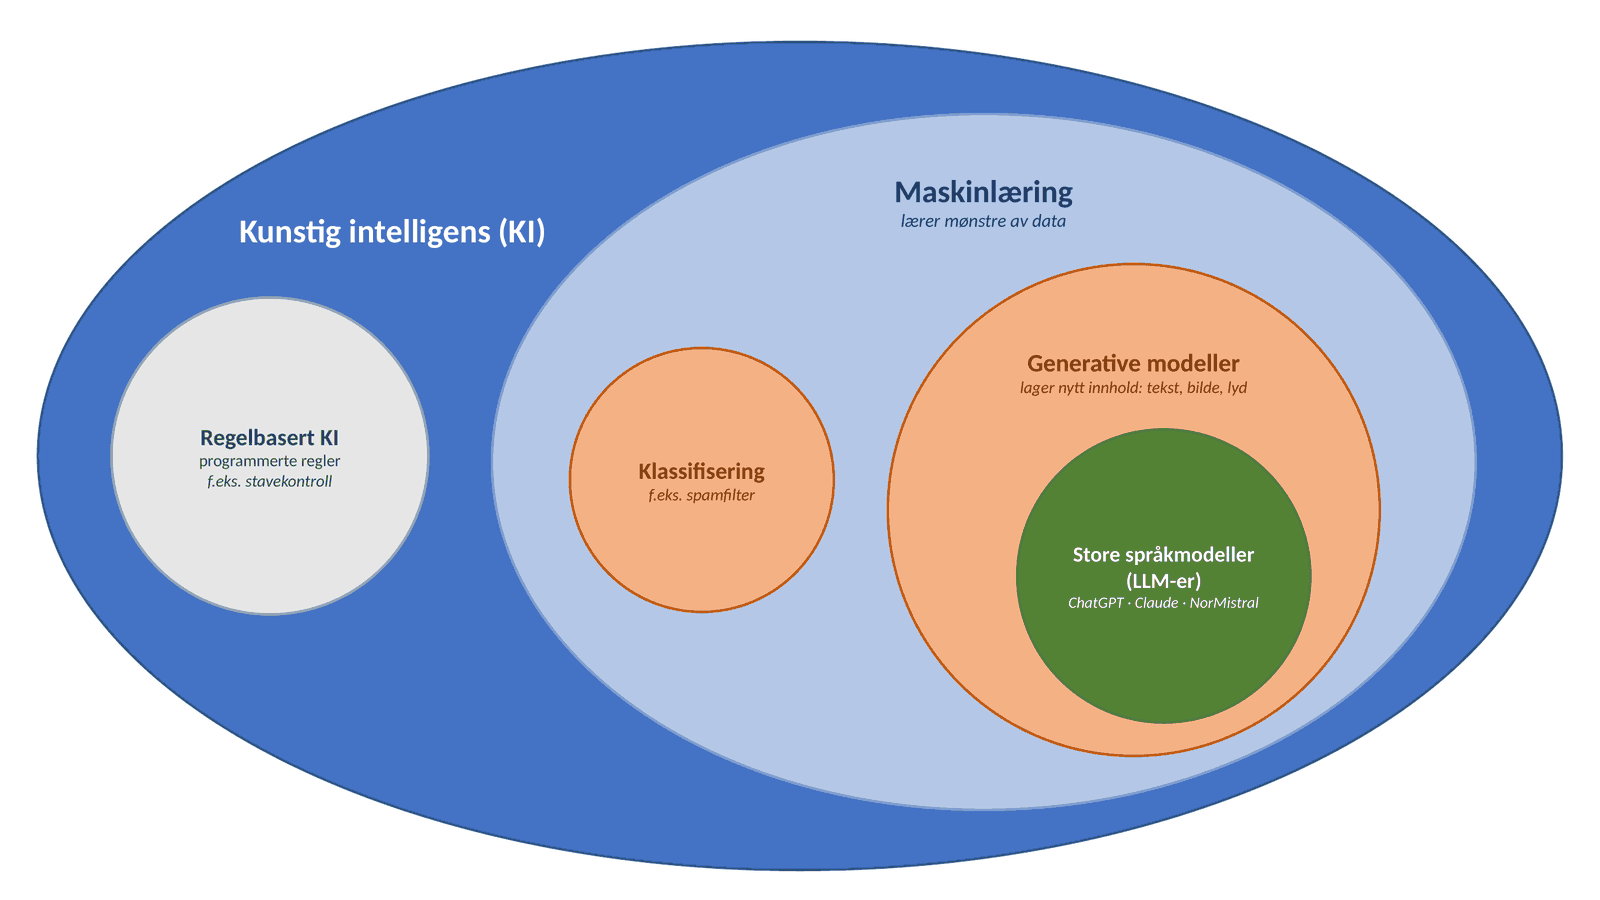">

# En språkmodell på nært hold 🔍

I denne notebooken møter du en **ferdigtrent språkmodell i miniatyr** – trent på *overordnet del
av læreplanen* (LK20). Den er ørliten sammenlignet med ChatGPT og Claude, men den fungerer etter
nøyaktig de samme prinsippene, og vi skal se hvordan den deler opp teksten vi skriver inn i orddeler og hvordan den genererer ny tekst. 

> **Tips:** Kjør cellene ovenfra og ned, én om gangen (▶️ eller `Shift + Enter`).
> Cellene med `input(...)` venter på at du skriver noe – se etter tekstfeltet som dukker opp.


In [ ]:
#@title 🔧 Oppsett (kjør meg først) { display-mode: "form" }
import warnings, torch
import html as html_verktoy
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
from transformers.utils import logging as hf_logging

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()

FARGER = ["#ffd6e7", "#d6eaff", "#d9f7d6", "#fff3c2", "#eadcff", "#ffe0c2", "#d6f5f2", "#e8e8e8"]

# biter: liste med token-strenger som skal vises som fargede bokser
def vis_bokser(biter):
    bokser = "".join(
        f'<span style="background:{FARGER[i % len(FARGER)]}; padding:3px 2px; margin:2px; '
        f'border-radius:4px; font-family:monospace; font-size:16px; display:inline-block">'
        f'{html_verktoy.escape(str(b))}</span>'
        for i, b in enumerate(biter))
    display(HTML(f'<div style="line-height:2.4">{bokser}</div>'))

# Modellen har et kontekstvindu: den kan bare ha et visst antall tokens "i hodet"
# om gangen. Denne sørger for at prompt + generert tekst holder seg innenfor det.
def klipp_til_kontekst(ids, onsket_lengde):
    kontekst = modell.config.n_positions
    if ids.shape[1] >= kontekst:
        print(f"⚠️ Prompten din er {ids.shape[1]} tokens, men modellen husker bare "
              f"{kontekst} – vi beholder de siste.")
        ids = ids[:, -(kontekst - 1):]
    return ids, min(onsket_lengde, kontekst - ids.shape[1])


print("Klar! 🚀")

## En språkmodell = tokenizer + modell 🧩

En språkmodell består av **to deler** som hører sammen:

1. **Tokenizeren** – oppskriften som deler tekst i biter (*tokens*) og gir hver bit et nummer
2. **Selve modellen** – de trente *vektene* (parameterne) som gjetter neste token

Jeg har lagt denne eksempelmodellen åpent tilgjengelig på [Hugging Face](https://huggingface.co) – verdens største
bibliotek for åpne modeller. Her kan alle laste opp sine modeller og de kan hentes ned av hvem som helst.
Det er dette som betyr at en modell er **åpen** i motsetning til de **lukkede** modellene til OpenAI, Google og Anthropic:


In [2]:
MODELLNAVN = "erlingmi/mini-laereplan-gpt"   # <- modellens adresse på Hugging Face

tokenizer = AutoTokenizer.from_pretrained(MODELLNAVN)     # del 1: tokenizeren
modell    = AutoModelForCausalLM.from_pretrained(MODELLNAVN)  # del 2: modellen (vektene)
modell.eval()

antall = sum(p.numel() for p in modell.parameters())
print(f"Lastet ned! Modellen har {antall:,} parametere.".replace(",", " "))
print("(ChatGPT og Claude har mange milliarder – men oppskriften er den samme.)")

Loading weights: 100%|██████████| 52/52 [00:00<00:00, 11938.46it/s]


Lastet ned! Modellen har 912 128 parametere.
(ChatGPT og Claude har mange milliarder – men oppskriften er den samme.)


In [ ]:
print(tokenizer.vocab_size, "tokens i vokabularet")
print(modell.config.n_positions, "tokens er det meste modellen kan ha «i hodet» om gangen (kontekstvinduet)")


## Test modellen selv! 🎛️

Cellen under er til deg: skriv din egen start, juster og kjør så mange ganger du vil.


In [ ]:
#@title ✍️ Skriv din egen start { display-mode: "form" }
min_start = "Elevene skal"   #@param {type:"string"}
lengde = 60                  #@param {type:"slider", min:20, max:120, step:10}
temperatur = 0.8             #@param {type:"slider", min:0.1, max:2.5, step:0.1}

ids_ = tokenizer(min_start, return_tensors="pt")["input_ids"]
ids_, lengde = klipp_til_kontekst(ids_, lengde)

resultat = modell.generate(ids_, max_new_tokens=lengde, do_sample=True,
                           temperature=float(temperatur), top_k=40,
                           eos_token_id=tokenizer.eos_token_id)[0]
print("«" + tokenizer.decode(resultat, skip_special_tokens=True).strip() + "»")


## Tenk over: ##
- Hvordan endrer teksten som blir generert seg når du stiller inn ulike lengde og temperatur?
- Lager modellen noen "unaturlige" ord? Hva kan være årsaken til det?

## Hvordan fungerer tokenizeren - fra tekst til tall 🔢

Skriv starten på en tekst i feltet under. Vi følger den gjennom modellens tre første trinn:

1. Teksten **deles i tokens** (orddeler) – tegnet `▁` betyr «nytt ord starter her»
2. Hvert token slås opp i vokabularet og blir et **tall** (token-id)
3. Tallrekken (listen med token_ids) er det eneste modellen ser


In [11]:
try:
    prompt = input("Skriv starten på en tekst: ").strip() or "Skolen skal"
except Exception:
    prompt = "Skolen skal"
    print(f"(ingen inndata – bruker eksempelet «{prompt}»)")

resultat = tokenizer.tokenize(prompt), tokenizer(prompt)["input_ids"]

print()
print("1) Prompten deles i tokens:")
vis_bokser(resultat[0])
print()
print("2) ... som slås opp og blir til tall:")
vis_bokser(resultat[1])


1) Prompten deles i tokens:



2) ... som slås opp og blir til tall:


In [24]:
"""
Fjern kryssene i koden under og kjør cellen hvis du har lyst til å se tokens for de første 50 tallene (token_ids) i vokabularet:
Du kan øke tallet 50 opp til 800 for å se alle tokens med id som finnes i vokabularet)
"""

#for i in range(30):
#    print("token_id:", i, "     Subword token: ", tokenizer.convert_ids_to_tokens(i))


'\nFjern kryssene i koden under og kjør cellen hvis du har lyst til å se tokens for de første 50 tallene (token_ids) i vokabularet:\nDu kan øke tallet 50 opp til 800 for å se alle tokens med id som finnes i vokabularet)\n'

## Modellen gjetter neste token 🎯

Nå gjør modellen det eneste den kan: Den ser på tallrekken og regner ut **hvor sannsynlig hvert
eneste token i vokabularet er som fortsettelse**. Her er topplista dens – og hva som skjer når
vi velger den øverste kandidaten:


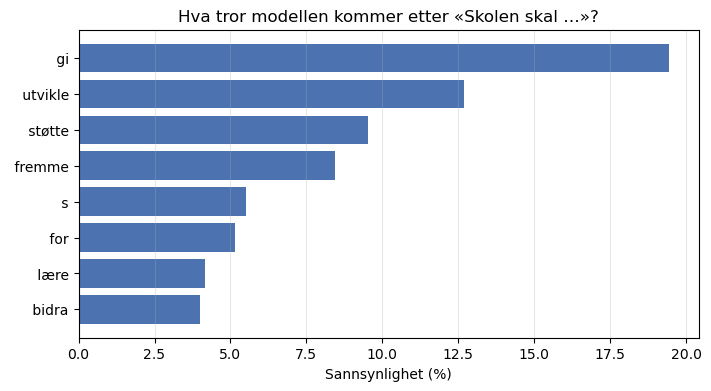

Velger vi toppkandidaten, har teksten vokst med ett token:

   «Skolen skal» + « gi»  →  «Skolen skal gi»


In [34]:
#Dette er promptet vi brukte tidligere. Du kan skrive din egen tekst på høyre side av likhetstegnet, men husk anførselstegn på begge sider.

prompt = prompt
#prompt = "Skolen skal"

ids = tokenizer(prompt, return_tensors="pt")["input_ids"]

with torch.no_grad():
    poengsummer = modell(ids).logits[0, -1]
sanns = torch.softmax(poengsummer, dim=-1)
verdier, hvilke = torch.topk(sanns, 8)

navn = [repr(tokenizer.decode([i]) or " ")[1:-1] for i in hvilke.tolist()]
plt.figure(figsize=(8, 4))
plt.barh(navn[::-1], (verdier * 100).tolist()[::-1], color="#4c72b0")
plt.xlabel("Sannsynlighet (%)")
plt.title(f"Hva tror modellen kommer etter «{prompt} …»?")
plt.grid(alpha=0.3, axis="x")
plt.show()

vinner = hvilke[0].item()
print(f"Velger vi toppkandidaten, har teksten vokst med ett token:")
print()
print(f"   «{prompt}» + «{tokenizer.decode([vinner])}»  →  «{tokenizer.decode(ids[0].tolist() + [vinner]).strip()}»")

## ... og slik blir det en hel tekst ✍️

Å generere tekst er bare å **gjenta dette** om og om igjen: 
- gjett neste token, heng det på slutten, gjett igjen.

Modellen fortsetter helt til den skriver et spesielt token – **`<eos>`** (*end of
sequence*, «slutt») – som den har lært å sette der avsnittene i treningsteksten sluttet.
Det er slik språkmodeller «vet» når de skal gi seg slik at de ikke fortsetter å generere tekst i det uendelige. I praksis setter vi også en makslengde for teksten som  genereres og når de når denne vil de uansett slutte, men da vil det sannsynligvis skje midt i en setning (og kanskje midt i et ord).


In [ ]:
set_seed(42)

input_ids, lengde = klipp_til_kontekst(ids, 120)

resultat = modell.generate(input_ids, max_new_tokens=lengde, do_sample=True,
                           temperature=0.7, top_k=40,
                           eos_token_id=tokenizer.eos_token_id)[0]

tekst = tokenizer.decode(resultat, skip_special_tokens=True).strip()
print(f"«{tekst}»")
print()
if resultat[-1].item() == tokenizer.eos_token_id:
    print("→ Modellen valgte selv å avslutte her: den genererte <eos>-tokenet. 🏁")
else:
    print(f"→ Modellen nådde maksgrensen vi satte ({lengde} tokens) før den rakk å skrive <eos>.")


In [ ]:
set_seed(42)

input_ids, lengde = klipp_til_kontekst(ids, 120)

resultat = modell.generate(input_ids, max_new_tokens=lengde, do_sample=True,
                           temperature=0.7, top_k=40,
                           eos_token_id=tokenizer.eos_token_id)[0]

tekst = tokenizer.decode(resultat, skip_special_tokens=True).strip()
print(f"«{tekst}»")
print()
if resultat[-1].item() == tokenizer.eos_token_id:
    print("→ Modellen valgte selv å avslutte her: den genererte <eos>-tokenet. 🏁")
else:
    print(f"→ Modellen nådde maksgrensen vi satte ({lengde} tokens) før den rakk å skrive <eos>.")


**Prøv dette:** Kjør cellen under som inneholder den samme koden i tillegg til en `input`-celle der du kan skrive din egen tekst.  

Skriv et **spørsmål** – for eksempel
*«Hva er tilpasset opplæring?»* – og kjør cellen under.

Du vil se at modellen **ikke svarer**. Den bare *fortsetter teksten* i læreplanstil, for det er
det eneste den er trent til. En modell som dette kalles en **basemodell**. At ChatGPT og Claude
*svarer* når du spør, skyldes ekstra opplæring som kommer *etter* dette stadiet – mer om det
neste gang!

---

> **Merk:** Minimodellen har et lite **kontekstvindu** – den kan bare ha et visst antall
> tokens «i hodet» om gangen (se tallet vi skrev ut helt i starten). Skriver du en lang tekst,
> kutter vi den, og svaret blir kortere. De store modellene har plass til hundretusener av
> tokens – men grensen finnes der også.


In [ ]:
set_seed(42)
prompt = input("Skriv din tekst her: ")
token_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]

print()
print("Slik ble teksten din delt opp i tokens:")
vis_bokser(tokenizer.tokenize(prompt))
print()

token_ids, lengde = klipp_til_kontekst(token_ids, 200)

resultat = modell.generate(token_ids, max_new_tokens=lengde, do_sample=True,
                           temperature=0.7, top_k=40,
                           eos_token_id=tokenizer.eos_token_id)[0]

tekst = tokenizer.decode(resultat, skip_special_tokens=True).strip()
print(f"«{tekst}»")
print()
if resultat[-1].item() == tokenizer.eos_token_id:
    print("→ Modellen valgte selv å avslutte her: den genererte <eos>-tokenet. 🏁")
else:
    print(f"→ Modellen nådde maksgrensen vi satte ({lengde} tokens) før den rakk å skrive <eos>.")


## Tenk over ##
Hva skjedde med spørsmålstegnet i promptet ditt? Hva kan være årsaken til det?

## Del B: Modellen er probabilistisk 🎲

La du merke til søylediagrammet? Modellen svarer aldri med *ett* token – den gir en
**sannsynlighetsfordeling**, og neste token **trekkes** fra den, som i et lotteri der de beste
forslagene har flest lodd.

Hvor vill trekningen skal være, styrer vi med **temperaturen** slik dere gjorde i begynnelsen:

In [48]:
#@title 🔧 Samme start, tre temperaturer { display-mode: "form" }
start = tokenizer("Opplæringen skal", return_tensors="pt")["input_ids"]

for temperatur in [0.2, 0.9, 2.2]:
    resultat = modell.generate(start, max_new_tokens=40, do_sample=True,
                               temperature=temperatur,
                               eos_token_id=tokenizer.eos_token_id)[0]
    print(f"Temperatur {temperatur}:")
    print(f"   «{tokenizer.decode(resultat, skip_special_tokens=True).strip()}»")
    print()

Temperatur 0.2:
   «Opplæringen skal gi elevene mulighet til å ha et godt grunnlag for å få hjelp og miljø ders og støtte i hjemmet.»

Temperatur 0.9:
   «Opplæringen skal respektere og dyrke fram forskjellige måter å utforske og skape på. Elevene skal lære og utvikle seg gjennom sansning og tenkning, estetiske uttrykksfor»

Temperatur 2.2:
   «Opplæringen skal lære. Skolen skal fremme tanktisk arvsattskap, oppslutningsprosesslingen. Skolen skal være i læringsarbeiden, og legge til rette for læring og øde formålsparagraf»



- **Lav temperatur (0.2):** Modellen holder seg til favorittene – ekte ord, trygg
  læreplanprosa (og til tider ordrette sitater fra treningsteksten!)
- **Middels (0.9):** Variert, men fortsatt gjenkjennelig
- **Høy (2.2):** Også usannsynlige orddeler får lodd i trekningen – og da rakner språket

I tillegg brukes gjerne **top-k**: Bare de *k* beste forslagene får være med i trekningen i det
hele tatt. Det kutter vekk den lange halen av tulleforslag:


In [49]:
#@title 🔧 Høy temperatur – med og uten top-k { display-mode: "form" }
for topp_k, forklaring in [(0, "uten top-k (alle 800 tokens kan trekkes)"),
                           (5, "top-k = 5 (bare de 5 beste kan trekkes)")]:
    resultat = modell.generate(start, max_new_tokens=40, do_sample=True, temperature=2.2,
                               top_k=topp_k, eos_token_id=tokenizer.eos_token_id)[0]
    print(f"Temperatur 2.2, {forklaring}:")
    print(f"   «{tokenizer.decode(resultat, skip_special_tokens=True).strip()}»")
    print()

Temperatur 2.2, uten top-k (alle 800 tokens kan trekkes):
   «Opplæringen skal grunnlag for skolens verdier og skal vokse til og forstå vil informasjon, i samisk para elevene som følge oppater hensynsfullelt og utvikle bevissthet om elevenes læring»

Temperatur 2.2, top-k = 5 (bare de 5 beste kan trekkes):
   «Opplæringen skal lære å utvise respekt for at alle får forståelse på ulike måter, og utvikle bevissthet om bådelever mestring, kommunikasjon og samarbeid som gir elevene dag, og trygghet»



## VIKTIG SANNSYNLIGHETSBEREGNING
## Men usikker? Nei – vi KAN skru av lotteriet 🎯

At modellen trekker tilfeldig, betyr ikke at den er «usikker». Tilfeldigheten er et **valg vi
gjør** fordi vi ønsker variasjon i språket. Dersom vi ønsker, kan vi gjøre den helt forutsigbar:

- **Grådig dekoding**: velg alltid toppkandidaten (dette er i praksis «temperatur 0»)
- **Fast seed**: lås lotteriet, så samme trekning skjer hver gang


In [50]:
#@title 🔧 Helt deterministisk – to måter { display-mode: "form" }
print("Grådig dekoding, kjørt to ganger:")
for _ in range(2):
    resultat = modell.generate(start, max_new_tokens=25, do_sample=False,
                               eos_token_id=tokenizer.eos_token_id)[0]
    print(f"   «{tokenizer.decode(resultat, skip_special_tokens=True).strip()}»")

print()
print("Sampling med fast seed (42), kjørt to ganger:")
for _ in range(2):
    set_seed(42)
    resultat = modell.generate(start, max_new_tokens=25, do_sample=True, temperature=0.8,
                               eos_token_id=tokenizer.eos_token_id)[0]
    print(f"   «{tokenizer.decode(resultat, skip_special_tokens=True).strip()}»")

print()
print("Identiske! Tilfeldigheten er altså et valg – ikke usikkerhet. 🎯")

Grådig dekoding, kjørt to ganger:
   «Opplæringen skal gi elevene forståelse for demokratiets spilleregler og betydningen av å holde disse i hevd.»
   «Opplæringen skal gi elevene forståelse for demokratiets spilleregler og betydningen av å holde disse i hevd.»

Sampling med fast seed (42), kjørt to ganger:
   «Opplæringen skal i demokratiet er verdier og demokratiet som styreform. Den skal gi elevene forståelse for demokratiets spil»
   «Opplæringen skal i demokratiet er verdier og demokratiet som styreform. Den skal gi elevene forståelse for demokratiets spil»

Identiske! Tilfeldigheten er altså et valg – ikke usikkerhet. 🎯


---

### Veien videre 🤔

Du har nå sett med egne øyne at en språkmodell er en **neste-orddel-gjetter**: tokens inn,
sannsynligheter ut, trekning – om og om igjen. Den *fortsetter* tekst, den *svarer* ikke, og den
har **ikke noe begrep om sant og usant** – den skriver bare det som er *plausibelt*. 

Veien herfra til ChatGPT, Claude og NorMistral handler om skala (milliarder av parametere,
millioner av dokumenter) og videretrening (instruksjonstrening og menneskelige
tilbakemeldinger) – og i **Del 2** av kurset skal vi trene en slik minimodell helt fra bunnen av
selv, og se på maskineriet inni: tokenisering, attention og de ulike modelltypene.


## Oppsummering ##

### 1. En språkmodell er aldri bedre enn sitt treningsgrunnlag - den kan bare svare på det den har lært.
### 2. En språkmodell må ha en tokenizer som deler opp naturlig språk i elementer som en matematisk modell kan forstå
### 3. En språkmodell beregner sannsynligheter for alle tokens og vi kan bestemme hvordan de skal velges ut. 
